In [1]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')
sys.path.insert(0, '../../../../../..')

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import evaluate_dls, dls_per_prefix_length, average_dls

# Guided decoding + reasoning
import suffix_pred.decision_rule_guided_reasoning_inference
importlib.reload(suffix_pred.decision_rule_guided_reasoning_inference)
from suffix_pred.decision_rule_guided_reasoning_inference import (
    DecisionGuidanceConfig,
    get_decision_guided_evaluator,
    GuidedMode,
    GuidedBeam,
    GuidedMCSA,
    )

# Decision labeling runtime models
import data_processing.decision_labeling
importlib.reload(data_processing.decision_labeling)
from data_processing.decision_labeling import DecisionLabeler

# Model
import suffix_pred.models.C_LSTM
importlib.reload(suffix_pred.models.C_LSTM)
from suffix_pred.models.C_LSTM import FullShared_Join_LSTM

In [2]:
# Model
file_path_model = '../../../../../../models/Helpdesk/clean/Helpdesk_C_LSTM_v1_clean.pkl'
model = FullShared_Join_LSTM.load(file_path_model)

# Load the data
file_path_test = '../../../../../../data/Helpdesk/tensor_data/normal/helpdesk_all_5_test.pkl'
test_dataset = torch.load(file_path_test, weights_only=False)

# Decision-mining artifacts for runtime decision guidance
petri_net_path = '../../../../../../data/Helpdesk/Petri_net/helpdesk.pkl'
decision_bundle_path = '../../../../../../data/Helpdesk/Petri_net/data_aware_Petri_net/decision_places_bundle.json'
decision_model_dir = '../../../../../../data/Helpdesk/Petri_net/data_aware_Petri_net/models'

with open(petri_net_path, 'rb') as f:
    net, im, fm = pickle.load(f)

# Attributes must match decision-mining training
dynamic_attributes = ["Resource", "case_elapsed_time", "event_elapsed_time"]
static_attributes = ["VariantIndex", "seriousness", "customer", "product",
                     "responsible_section", "seriousness_2", "service_level",
                     "service_type", "support_section", "workgroup"]

decision_labeler = DecisionLabeler(
    petri_net=(net, im, fm),
    decision_model_dir=decision_model_dir,
    decision_places_bundle_path=decision_bundle_path,
    dynamic_attributes=dynamic_attributes,
    static_attributes=static_attributes,
)

guidance_cfg = DecisionGuidanceConfig(
    epsilon=1e-3,
    beta_max=2.0,
    alpha=0.10,
    support_threshold=0.05,
    )

print('Model and decision guidance artifacts loaded.')

Data set categories:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Model input features:  [['Activity', 'Resource'], ['case_elapsed_time']]


Embeddings:  ModuleList(
  (0): Embedding(15, 7)
  (1): Embedding(24, 9)
)
Total embedding feature size:  16
Input feature si

/home/PSPLab/.local/share/virtualenvs/decision_aware_augmentation_for_PPM-0DzgvVpC/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Model and decision guidance artifacts loaded.


/home/PSPLab/ProbabilisticSuffixPredictionLab/decision_aware_augmentation_for_PPM/src/notebooks/suffix_prediction/evaluation/Helpdesk/decision_decoding/../../../../../data_processing/decision_labeling.py:278: UserWarning: Decision place p_22: 4 unmatched model→net UUIDs; cannot auto-remap.
  warnings.warn(


In [3]:
# Step 1: Guided decode suffixes (mode / arg-max with local decision reweighting)
guided_mode_eval = get_decision_guided_evaluator(
    kind='mode',
    model=model,
    dataset=test_dataset,
    decision_labeler=decision_labeler,
    guidance_config=guidance_cfg,
    decision_places_bundle_path=decision_bundle_path,
    concept_name='Activity',
    eos_value='EOS',
)

guided_mode_outputs = []
guided_mode_reasoning = []

for case_id, prefix_len, prefix, target_suffix, decoded_suffixes, reasoning in guided_mode_eval.evaluate(
    random_order=False,
    return_reasoning=True,
    ):
    guided_mode_outputs.append({
        'case_id': case_id,
        'prefix_len': int(prefix_len),
        'prefix': prefix,
        'target_suffix': target_suffix,
        'decoded_suffixes': decoded_suffixes,
        'mode': 'guided_mode',
    })
    guided_mode_reasoning.append({
        'case_id': case_id,
        'prefix_len': int(prefix_len),
        'reasoning': reasoning,
    })

cache_outputs_path = '../../../../../../eval_results/Helpdesk/decision_train/helpdesk_c_lstm_guided_mode_outputs_decision_train.pkl'
cache_reasoning_path = '../../../../../../eval_results/Helpdesk/decision_train/helpdesk_c_lstm_guided_mode_reasoning_decision_train.pkl'

with open(cache_outputs_path, 'wb') as f:
    pickle.dump(guided_mode_outputs, f)
with open(cache_reasoning_path, 'wb') as f:
    pickle.dump(guided_mode_reasoning, f)

print(f"Decoded {len(guided_mode_outputs)} prefix rows in 'guided_mode'.")

# Step 2: Evaluate DLS from guided decoded outputs
guided_mode_df = evaluate_dls(guided_mode_outputs)
guided_mode_per_prefix = dls_per_prefix_length(guided_mode_df)
guided_mode_avg = average_dls(guided_mode_df)

# Step 3: Aggregate decision-conflict diagnostics
decision_steps = sum(r['reasoning']['decision_steps'] for r in guided_mode_reasoning)
conflicts = sum(r['reasoning']['conflicts'] for r in guided_mode_reasoning)
conflict_rate = (conflicts / decision_steps) if decision_steps > 0 else 0.0

print(f"Average DLS (guided_mode) on full test set: {guided_mode_avg:.4f}")
print(f"Decision steps: {decision_steps} | Conflicts: {conflicts} | Conflict rate: {conflict_rate:.4f}")

  0%|          | 0/916 [00:00<?, ?it/s]

Decoded 3343 prefix rows in 'guided_mode'.
Average DLS (guided_mode) on full test set: 0.9297
Decision steps: 4673 | Conflicts: 0 | Conflict rate: 0.0000


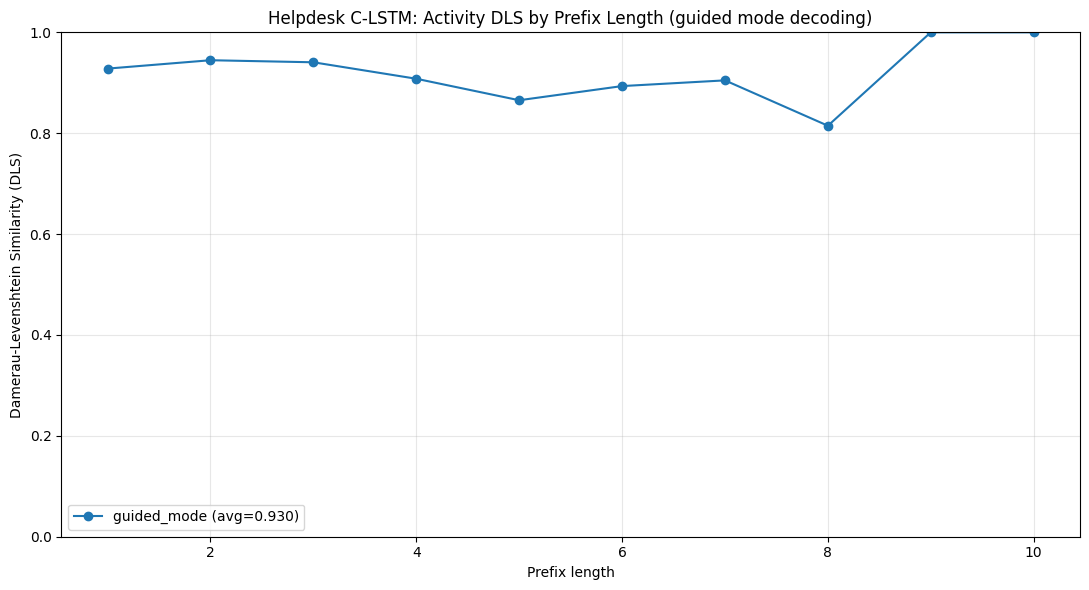

,mode,average_dls,decision_steps,conflicts,conflict_rate
0,guided_mode,0.929676,4673,0,0.0


In [4]:
# Plot DLS by prefix length for guided mode
plt.figure(figsize=(11, 6))

plt.plot(guided_mode_per_prefix['prefix_len'],
         guided_mode_per_prefix['dls'],
         marker='o',
         label=f"guided_mode (avg={guided_mode_avg:.3f})")

plt.title('Helpdesk C-LSTM: Activity DLS by Prefix Length (guided mode decoding)')
plt.xlabel('Prefix length')
plt.ylabel('Damerau-Levenshtein Similarity (DLS)')
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'mode': ['guided_mode'],
    'average_dls': [guided_mode_avg],
    'decision_steps': [decision_steps],
    'conflicts': [conflicts],
    'conflict_rate': [conflict_rate],
}).sort_values('average_dls', ascending=False).reset_index(drop=True)
summary

In [5]:
# Inspect guided predictions and rule-based reasoning for examples
with open('../../../../../../eval_results/Helpdesk/decision_train/helpdesk_c_lstm_guided_mode_outputs_decision_train.pkl', 'rb') as f:
    cached_outputs = pickle.load(f)

with open('../../../../../../eval_results/Helpdesk/decision_train/helpdesk_c_lstm_guided_mode_reasoning_decision_train.pkl', 'rb') as f:
    cached_reasoning = pickle.load(f)

for i in range(min(15, len(cached_outputs))):
    row = cached_outputs[i]
    reason = cached_reasoning[i]['reasoning']

    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:            {row['prefix']}")
    print(f"  Target suffix:     {row['target_suffix']}")
    decoded = row['decoded_suffixes']
    print(f"  Predicted suffix:  {decoded[0] if len(decoded) > 0 else []}")
    print(f"  Decision steps: {reason['decision_steps']} | Conflicts: {reason['conflicts']} | Conflict rate: {reason['conflict_rate']:.4f}")

    trace = reason.get('trace', [])
    if len(trace) > 0:
        first_step = trace[0]
        print(f"  First decision step: {first_step['input_event']} -> {first_step['next_event']} at place {first_step['place']}")
        if first_step.get('matched_rule') is not None:
            print(f"  Matched rule: {first_step['matched_rule']['rule']}")
    print()

Case: Case 1003  |  Prefix len: 1
  Prefix:            ['Assign seriousness']
  Target suffix:     ['Take in charge ticket', 'Resolve ticket', 'Closed']
  Predicted suffix:  ['Take in charge ticket', 'Resolve ticket', 'Closed']
  Decision steps: 2 | Conflicts: 0 | Conflict rate: 0.0000
  First decision step: Assign seriousness -> Take in charge ticket at place p_9

Case: Case 1003  |  Prefix len: 2
  Prefix:            ['Assign seriousness', 'Take in charge ticket']
  Target suffix:     ['Resolve ticket', 'Closed']
  Predicted suffix:  ['Resolve ticket', 'Closed']
  Decision steps: 1 | Conflicts: 0 | Conflict rate: 0.0000
  First decision step: Take in charge ticket -> Resolve ticket at place p_16

Case: Case 1003  |  Prefix len: 3
  Prefix:            ['Assign seriousness', 'Take in charge ticket', 'Resolve ticket']
  Target suffix:     ['Closed']
  Predicted suffix:  ['Closed']
  Decision steps: 0 | Conflicts: 0 | Conflict rate: 0.0000

Case: Case 1004  |  Prefix len: 1
  Prefix:    